In [61]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [62]:
filename1 = "affected_laplacian_zero_dimension.pkl"
filename2 = "affected_laplacian_first_dimension.pkl"
filename3 = "affected_laplacian_second_dimension.pkl"
filename4 = "healthy_laplacian_zero_dimension.pkl"
filename5 = "healthy_laplacian_first_dimension.pkl"
filename6 = "healthy_laplacian_second_dimension.pkl"

In [63]:
with open(filename1, "rb") as f:
    affected_laplacian_red_feature = pickle.load(f)

In [64]:
with open(filename2, "rb") as f:
    affected_laplacian_green_feature = pickle.load(f)

In [65]:
with open(filename3, "rb") as f:
    affected_laplacian_blue_feature = pickle.load(f)

In [66]:
with open(filename4, "rb") as f:
    healthy_laplacian_red_feature = pickle.load(f)

In [67]:
with open(filename5, "rb") as f:
    healthy_laplacian_green_feature = pickle.load(f)

In [68]:
with open(filename6, "rb") as f:
    healthy_laplacian_blue_feature = pickle.load(f)

In [69]:
filename7 = "affected_area_feature_2.pkl"
filename8 = "healthy_area_feature_2.pkl"

In [70]:
with open(filename7, "rb") as f:
    affected_area_feature = pickle.load(f)

In [71]:
with open(filename8, "rb") as f:
    healthy_area_feature = pickle.load(f)

In [72]:
filename9  = "affected_perimeter_feature.pkl"
filename10 = "healthy_perimeter_feature.pkl"

In [73]:
with open(filename9, "rb") as f:
    affected_perimeter_feature = pickle.load(f)

In [74]:
with open(filename10, "rb") as f:
    healthy_perimeter_feature = pickle.load(f)

In [75]:
print(len(affected_laplacian_red_feature))
print(len(affected_laplacian_green_feature))
print(len(affected_laplacian_blue_feature))
print(len(affected_area_feature))
print(len(affected_perimeter_feature))

335
335
335
335
335


In [76]:
print(len(healthy_laplacian_red_feature))
print(len(healthy_laplacian_green_feature))
print(len(healthy_laplacian_blue_feature))
print(len(healthy_area_feature))
print(len(healthy_perimeter_feature))

413
413
413
413
413


In [77]:
red_feature = affected_laplacian_red_feature + healthy_laplacian_red_feature
green_feature = affected_laplacian_green_feature + healthy_laplacian_green_feature
blue_feature = affected_laplacian_blue_feature + healthy_laplacian_blue_feature
area_feature = affected_area_feature + healthy_area_feature
perimeter_feature = affected_perimeter_feature + healthy_perimeter_feature

In [78]:
print(len(red_feature))
print(len(green_feature))
print(len(blue_feature))
print(len(area_feature))
print(len(perimeter_feature))

748
748
748
748
748


In [79]:
label_zero = [0] * 335
label_one = [1] * 413
label = label_zero + label_one

In [80]:
print(len(label))

748


In [81]:
# Create the dataset
dataset = pd.DataFrame({
    'LaplacianRed': red_feature,
    'LaplacianGreen': green_feature,
    'LaplacianBlue': blue_feature,
    'Area': area_feature,
    'Perimeter': perimeter_feature,
    'Label': label
})

In [82]:
dataset = dataset.sample(frac=1).reset_index(drop=True)

In [83]:
dataset

,LaplacianRed,LaplacianGreen,LaplacianBlue,Area,Perimeter,Label
0,7291475,6929744,3238679,33513.5,755.050859,0
1,7709804,6978373,3019732,25038.5,779.712765,0
2,9886263,6720644,4328773,42592.5,1210.090401,0
3,8196057,6801971,4841460,32986.0,746.055910,0
4,5587941,8423835,4543872,4801.0,673.955406,1
...,...,...,...,...,...,...
743,7267111,5516958,3736681,13984.5,913.896531,0
744,6206076,5248545,2536990,27799.5,658.097540,0
745,1843846,5511360,3069910,33154.0,1059.639609,1
746,1890348,9697661,2894167,15922.5,892.000000,1


In [84]:
X = dataset.drop('Label', axis=1)
y = dataset['Label']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [87]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91        64
           1       0.95      0.91      0.93        86

    accuracy                           0.92       150
   macro avg       0.92      0.92      0.92       150
weighted avg       0.92      0.92      0.92       150



In [88]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [89]:
print(cm)

[[60  4]
 [ 8 78]]


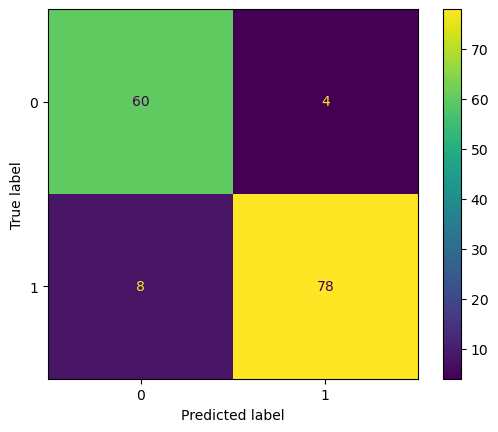

In [90]:
# Optional: Display as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

/var/folders/x1/jqxrt94s0ggfl8m0z5bftpz80000gn/T/ipykernel_1440/1556446823.py:9: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


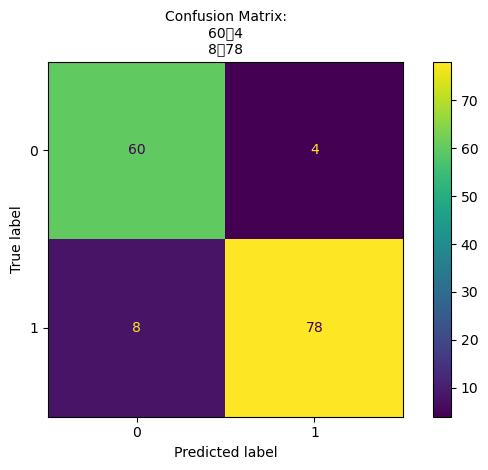

In [91]:
# Your code to compute cm and model.classes_ should be above this
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

# Convert confusion matrix to string and set it as title
cm_string = '\n'.join(['\t'.join(map(str, row)) for row in cm])
plt.title(f"Confusion Matrix:\n{cm_string}", fontsize=10)

plt.tight_layout()
plt.show()